# Benchmarking a range of architectures

## Balanced log loss

Log loss measures performance based on outputted probabilities:

$\text{Log Loss} = -\frac{1}{N} \sum_{i=1}^{N} \left( y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right)$

This does not account for class imbalance. A model may receive a good (low) log loss by frequently predicting the majority class, potentially
misleading the evaluation.
Balanced log loss assigns weights to the classes with the minority class receiving higher weights:

$\text{Balanced Log Loss} = -\frac{1}{N} \sum_{i=1}^{N} w_i \left( y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right)$

By increasing focus on the minority
class, the metric score better reflects the model's ability to classify both clases in the context of an imbalanced dataset.
Different weighting strategies can be used. Here, inverse prevalence weights are used, but weights may also be set manually using domain knowledge.
Balanced log loss may be used as the training loss and as an evaluation metric.
For implementation, I assign inverse prevalence weights according to the class frequencies,
then rescale the probablities to avoid finding the logarithm of zero or one. The log loss is calcuated seperately for the positive and negative classes,
and the weighted average of these is computed.

In [83]:
def calculate_balanced_log_loss(pred_prob, true_label):
    N_neg = np.sum(true_label == 0)
    N_pos = np.sum(true_label == 1)

    if N_neg == 0 or N_pos == 0:
        raise ValueError("Zero instances of one or both classes")

    # Inverse prevalence weights
    weight_neg = 1 / N_neg
    weight_pos = 1 / N_pos

    # Rescale to avoid numerical instability 
    pred_prob = np.clip(pred_prob, 1e-15, 1 - 1e-15)

    # Log loss for each class
    log_loss_neg = np.sum((1 - true_label) * np.log(1 - pred_prob)) / N_neg
    log_loss_pos = np.sum(true_label * np.log(pred_prob)) / N_pos

    return (-weight_neg * log_loss_neg -weight_pos * log_loss_pos) / (weight_neg + weight_pos)


def calculate_metrics(probabilities, true_labels, threshold=0.5):
    metrics = [f(probabilities, true_labels, threshold)
               for f in (calculate_precision, calculate_recall, calculate_f1,
                         calculate_accuracy, calculate_mcc, calculate_cohens_kappa, 
                         calculate_lift)]
    metrics_dict = dict(zip(['precision', 'recall', 'f1', 'accuracy', 'mcc', 'kappa', 'lift'], metrics))
    metrics_dict['roc_auc'] = roc_auc(probabilities, true_labels, plot=False) 
    metrics_dict['balanced_log_loss'] = calculate_balanced_log_loss(probabilities, true_labels)

    return metrics_dict


def calculate_metric(prob, label, metric='roc_auc', threshold=0.5):
    if metric == 'roc_auc':
        return roc_auc(prob, label, plot=False)
    if metric == 'balanced_log_loss':
        return calculate_balanced_log_loss(prob, label)
    
    metrics_f = [calculate_precision, calculate_recall, calculate_f1,
                  calculate_accuracy, calculate_mcc, calculate_cohens_kappa, 
                  calculate_lift]
    metrics_dict = dict(zip(['precision', 'recall', 'f1', 'accuracy', 'mcc', 'kappa', 'lift'], metrics_f))
    
    return metrics_dict[metric](prob, label, threshold)
    


## Algorithm zoo

There are many potential approaches. For example, stacking combines predictions from multiple heterogenous models into a meta-classifier. However, for simplicity, I implement several individual models and compare performance, avoiding the increased complexity, training durations, and more difficult hyperparameter tuning with stacking.
Stratified k-fold with undersampling (training folds only) is applied on the 10 original features. The models are: Logistic Regression, Ridge Classifier, Random Forest, Support Vector Classifier, k-Nearest Neighbors, Decision Tree,
Naive Bayes, Extra Trees, Multilayer Perceptron, Gradient Boosting, XGBoost, LightGBM, and CatBoost.
These represent a diverse set of approaches, including linear models
(logistic regrssion), instance-based learning (k-NN), tree-based and ensemble
methods. Top models are chosen for feature engineering and hyperparameter tuning.

In [126]:
import concurrent.futures
import time

def train_model_get_metrics(args, classifier, X_train, y_train, X_val, y_val):
    classifier.fit(X_train, y_train)
    
    try:
        train_pred = classifier.predict_proba(X_train)[:, 1]  # get +ve class prob
        val_pred = classifier.predict_proba(X_val)[:, 1]
    except AttributeError:  # e.g. RidgeClassifier has no predict_proba
        train_pred = classifier.predict(X_train)
        val_pred = classifier.predict(X_val)
    
    train_err = 1 - calculate_metric(train_pred, y_train, metric='accuracy')
    val_metrics = calculate_metrics(val_pred, y_val)
    val_err = 1 - val_metrics['accuracy']
    
    return classifier, train_err, val_err, val_metrics


def preprocess_train(args, X_train, y_train):
    method = args.get('balance_method', 'none')
    if method == 'undersample':
        X_train, y_train = undersample_neg(args, X_train, y_train, adaboost_labels=False)
    elif method == 'smote':
        X_train, y_train = smote_oversample_pos(args, X_train, y_train)    
    
    return X_train, y_train


def preprocess_train_metrics(args, classifier, X, label, train_indices, val_indices):
    local_args = args.copy()
    local_args['silent'] = True
    
    X_train, y_train = [df.iloc[train_indices].reset_index(drop=True) for df in (X, label)]
    X_val, y_val = [df.iloc[val_indices].reset_index(drop=True) for df in (X, label)]

    X_train, y_train = preprocess_train(args, X_train, y_train)

    classifier, train_err, val_err, val_metrics = train_model_get_metrics(
        local_args, classifier, X_train, y_train, X_val, y_val)
    
    return classifier, train_err, val_err, val_metrics


def train_k_fold(args, classifier, X, y, k=5, stratified=False, parallel=False):
    start_time = time.time()
    
    fold_indices = get_fold_indices(X, y, k, stratified, adaboost_labels=False)
    results = []

    if parallel:
        futures = []
        with concurrent.futures.ProcessPoolExecutor() as executor:
            for train, val in fold_indices:
                futures.append(executor.submit(preprocess_train_metrics, args, classifier, X, y, train, val))    

            for future in concurrent.futures.as_completed(futures):
                classifier, train_err, val_err, val_metrics = future.result()
                results.append((classifier, train_err, val_err, val_metrics))
    else:
        for train, val in fold_indices:
            classifier, train_err, val_err, val_metrics = preprocess_train_metrics(args, classifier, X, y, train, val)
            results.append((classifier, train_err, val_err, val_metrics))        

    elapsed_time = time.time() - start_time
    print(f"Completed cross-validation in {elapsed_time} seconds.")
    
    return results


In [121]:
args = {
    # Data
    'base_dir': '/kaggle/input/playground-series-s4e7/',

    # Misc
    'random_state': 123,
    'use_gpu': False
}

In [87]:
from sklearn.ensemble import (GradientBoostingClassifier, RandomForestClassifier, 
                              AdaBoostClassifier, ExtraTreesClassifier)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

In [122]:
xgb_device, lgbm_device, cat_device = ('gpu', 'gpu', 'GPU') if args['use_gpu'] else ('cpu', 'cpu', 'CPU')

In [123]:
models = [
    (LogisticRegression(max_iter=200), 'Logistic Regression'),
    (RidgeClassifier(), 'Ridge Classifier'),
    (RandomForestClassifier(class_weight='balanced'), 'Random Forest'),
    (SVC(probability=True, class_weight='balanced'), 'Support Vector Classifier'),
    (KNeighborsClassifier(), 'k-Nearest Neighbors'),
    (DecisionTreeClassifier(), 'Decision Tree'),
    (GaussianNB(), 'Naive Bayes'),
    (ExtraTreesClassifier(), 'Extra Trees'),
    (MLPClassifier(), 'MLP'),
    (GradientBoostingClassifier(), 'Gradient Boosting'),
    (XGBClassifier(device=xgb_device), 'XGBoost'),
    (LGBMClassifier(device_type=lgbm_device), 'LightGBM'),
    (CatBoostClassifier(task_type=cat_device, logging_level='Silent'), 'CatBoost')
]

In [9]:
df_train = pd.read_csv(args['base_dir'] + 'train.csv')
X, y = split_response(df_train)

In [10]:
args['N'] = 100000
X_strat, y_strat = sample_stratified(args, X, y)
X_strat = encode_data(X_strat)
print('\nSampled data\n--\n', y_strat.shape, y_strat.value_counts())


Sampled data
--
 (100000,) Response
0    87701
1    12299
Name: count, dtype: int64


I scale the data to ensure models are evaluated under similar conditions, as some models (e.g. k-NN, SVC) are sensitive to scaling,
while others are either unaffected (e.g. Random Forests, Decision Trees) or
enjoy improved performance with scaled data.

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_strat = pd.DataFrame(scaler.fit_transform(X_strat))
X_strat.head()

,0,1,2,3,4,5,6,7,8,9
0,-1.095819,0.044088,1.504517,1.080620,-1.066691,-1.009546,0.037251,0.730767,1.346529,0.918490
1,1.104937,0.044088,-2.034674,-0.925395,0.693496,0.990545,-1.699924,0.173977,0.872939,-1.088744
2,0.771489,0.044088,0.119616,-0.925395,0.693496,0.990545,0.354816,-1.607751,0.137627,0.918490
3,0.304662,0.044088,-1.034468,-0.925395,0.693496,-1.009546,-1.699924,0.211096,1.521009,0.918490
4,-0.895750,0.044088,0.812067,1.080620,-1.066691,-1.009546,-1.699924,0.211096,1.383918,-1.088744


In [3]:
args['balance_method'] = 'undersample'

In [115]:
def cross_validate_models(args, models, X, y, stratified=True):
    val_metrics = {}

    for model in models:
        parallel = False if args['use_gpu'] == True and model[1] in ['XGBoost', 'LightGBM', 'CatBoost'] else args.get('parallel', False)
        print(f"Cross-validating: {model[1]}")
        results = train_k_fold(args, model[0], X, y, k=5, stratified=stratified, parallel=parallel)
        val_metrics[model[1]] = avg_metrics([results[i][3] for i in range(len(results))])
        
    return val_metrics

In [13]:
val_metrics = cross_validate_models(args, models, X_strat, y_strat)
val_metrics

{'Logistic Regression': {'precision': 0.2532156734504526,
  'recall': 0.9816185441236275,
  'f1': 0.4025821376025028,
  'accuracy': 0.6417820891044552,
  'mcc': 0.3785558286766999,
  'kappa': 0.2574182258900196,
  'lift': 2.0593982323446935,
  'roc_auc': 0.8362070568497822,
  'balanced_log_loss': 0.3875010205653582},
 'Ridge Classifier': {'precision': 0.25313980581640944,
  'recall': 0.9821065473769826,
  'f1': 0.4025272698211039,
  'accuracy': 0.6415220761038052,
  'mcc': 0.3786233890129741,
  'kappa': 0.25732052573991776,
  'lift': 2.058781202327114,
  'roc_auc': 0.5884618762528732,
  'balanced_log_loss': 2.2672100658333165},
 'Random Forest': {'precision': 0.2864397930445661,
  'recall': 0.896868645790972,
  'f1': 0.4342017904287343,
  'accuracy': 0.7125956297814892,
  'mcc': 0.3938792100624232,
  'kappa': 0.3045861396406123,
  'lift': 2.329609361975713,
  'roc_auc': 0.8465153697375847,
  'balanced_log_loss': 0.4143775968407102},
 'Support Vector Classifier': {'precision': 0.2830604

In [63]:
def print_best_models(val_metrics, metric, higher_is_better=True, n_models=5):
    sorted_models = sorted(val_metrics.items(), key=lambda x: x[1][metric], reverse=higher_is_better)
    top_n = sorted_models[:n_models]
    top_n_reduced = [(model[0], model[1][metric]) for model in top_n]
    print(f"Top {n_models} models based on {metric}:")
    for i in top_n_reduced: print(f'{i[0]}: {i[1]}')

print_best_models(val_metrics, 'balanced_log_loss', higher_is_better=False)
print('--')
print_best_models(val_metrics, 'roc_auc', higher_is_better=True)

Top 5 models based on balanced_log_loss:
CatBoost: 0.36799971208093707
LightGBM: 0.3696953315517565
Gradient Boosting: 0.3700093246217586
XGBoost: 0.3817324556900549
MLP: 0.38494738774917436
--
Top 5 models based on roc_auc:
CatBoost: 0.8627689964911435
LightGBM: 0.861691930093673
Gradient Boosting: 0.8604312016964188
XGBoost: 0.8565531547481318
MLP: 0.8507247200728202


Based on both the balanced log loss and ROC/AUC scores, the top performers in the initial trial are CatBoost, LightGBM, Gradient Boosting, XGBoost, and MLP. The MLP failed to converge with the default maximum iterations (200) so I set this to 300.

In [43]:
mlp = (MLPClassifier(max_iter=300), 'MLP')
print(f"Cross-validating: MLP")
mlp_results = train_k_fold(args, mlp[0], X_strat, y_strat, k=5, stratified=True)
mlp_metrics = avg_metrics([mlp_results[i][3] for i in range(len(mlp_results))])

Cross-validating: MLP
Completed cross-validation in 33.95518779754639 seconds.


In [36]:
mlp_metrics

{'precision': 0.28571261936589387,
 'recall': 0.9191541276941846,
 'f1': 0.43589063317473425,
 'accuracy': 0.7074553727686385,
 'mcc': 0.4009321852318489,
 'kappa': 0.30563013094858305,
 'lift': 2.3236952723458764,
 'roc_auc': 0.8491120371817302,
 'balanced_log_loss': 0.3788408012017014}

This improved the balanced log loss and ROC/AUC scores. Hence, I continue with these models.

In [3]:
val_metrics['MLP'] = mlp_metrics

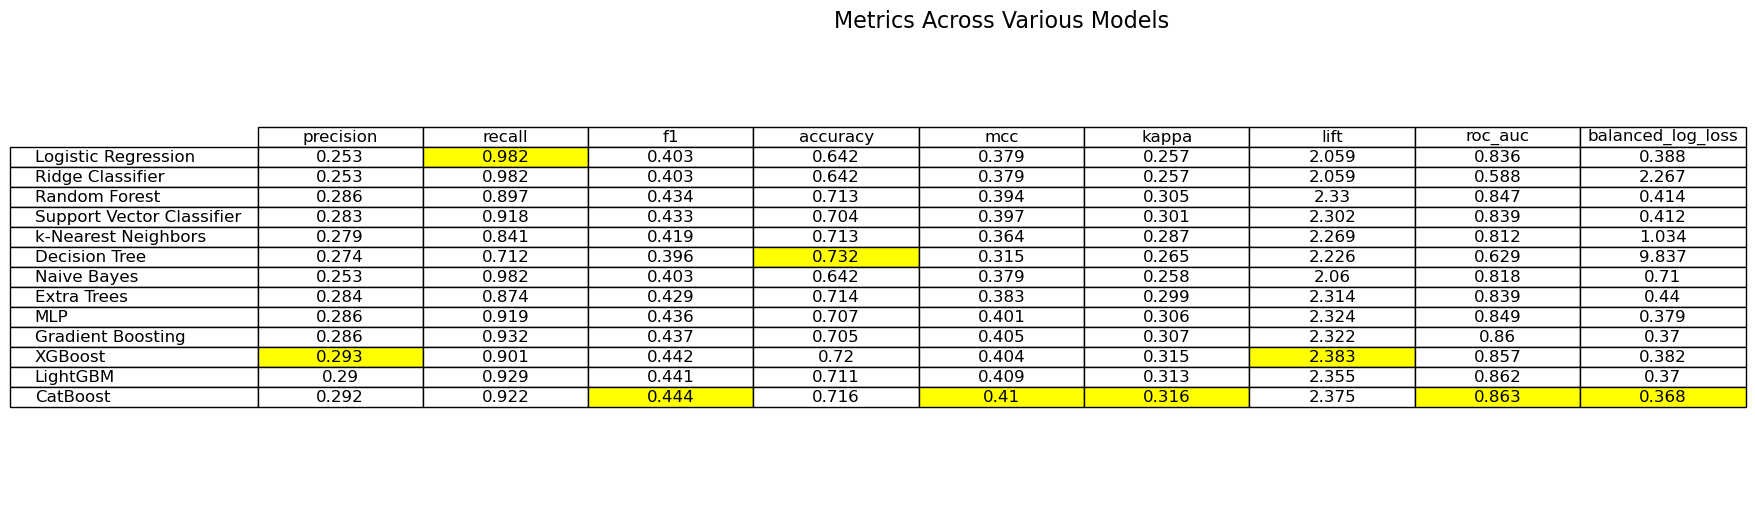

In [27]:
metrics = ['precision', 'recall', 'f1', 'accuracy', 'mcc', 'kappa', 'lift', 'roc_auc', 'balanced_log_loss']
models = list(val_metrics.keys())

data = np.array([[val_metrics[model][metric] for metric in metrics] for model in models])
data = np.round(data, 3)

# Create the table
fig, ax = plt.subplots(figsize=(16, 6))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=data, colLabels=metrics, rowLabels=models, cellLoc='center', loc='center')

for col in range(len(metrics) - 1): # for balanced log loss
    max_index = np.argmax(data[:, col]) + 1 # +1 for header
    table[(max_index, col)].set_facecolor('yellow')

min_bll = np.argmin(data[:, -1]) + 1
table[(min_bll, 8)].set_facecolor('yellow')
    
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)
plt.title("Metrics Across Various Models", fontsize=16)
plt.show()

XGBoost, LightGBM and CatBoost achieve the highest precision, effectively identifying positive cases.
While Logistic Regression and the Ridge Classifier had poor precision, they had good recall, capturing more true positives.
However, the boosting models also achieve the strongest F1 scores, better balancing precision and recall.

Decision Tree has the highest accuracy but this may reflect validation imbalance.
CatBoost, followed by LightGBM and XGBoost, has the highest MCC and Cohen's Kappa, indicating strong overall prediction quality. Lift is highest for XGBoost, then CatBoost, outperforming random selection.
CatBoost and LightGBM have the best ROC/AUC scores reflecting good class separation, while CatBoost, LightGBM and Gradient Boosting achieve the lowest balanced log loss.

Overall, boosting (CatBoost, XGBoost, LightGBM, and Gradient Boosting)
perform best across key metrics and are selected as primary candidates. 
MLP is included for diversity due to its relatively strong performance, particularly ROC/AUC. I focus on minimising balanced log loss
while maximising ROC/AUC, which the Kaggle score uses.

In [124]:
models = [
    (MLPClassifier(max_iter=300), 'MLP'),
    (GradientBoostingClassifier(), 'Gradient Boosting'),
    (XGBClassifier(device=xgb_device), 'XGBoost'),
    (LGBMClassifier(device_type=lgbm_device, verbose=0), 'LightGBM'),
    (CatBoostClassifier(task_type=cat_device, logging_level='Silent'), 'CatBoost')
]

## Data balancing

In part `01` I show that downsampling negatives yields best performance with AdaBoost. However, this may not hold for other models, so I repeat balancing experiments here.
I take a stratified sample and use stratified k-fold CV for a baseline.
Results are compared to balancing the training folds, leaving the validation fold imbalanced.

In [16]:
args['balance_method'] = 'smote'
val_metrics_smote = cross_validate_models(args, models, X_strat, y_strat)

Cross-validating: MLP
Completed cross-validation in 852.4510939121246 seconds.
Cross-validating: Gradient Boosting
Completed cross-validation in 65.1063163280487 seconds.
Cross-validating: XGBoost
Completed cross-validation in 101.90167474746704 seconds.
Cross-validating: LightGBM
[LightGBM] [Info] Number of positive: 70161, number of negative: 70161[LightGBM] [Info] Number of positive: 70161, number of negative: 70161

[LightGBM] [Info] Number of positive: 70161, number of negative: 70161[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035579 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033395 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.[LightGBM] [Info] Number of positive: 70161, number of n

In [18]:
print_best_models(val_metrics_smote, 'balanced_log_loss', higher_is_better=False)
print('--')
print_best_models(val_metrics_smote, 'roc_auc', higher_is_better=True)

Top 5 models based on balanced_log_loss:
MLP: 0.43287359418587956
Gradient Boosting: 0.44568723379474057
XGBoost: 0.707643427506817
LightGBM: 0.7202186129017807
CatBoost: 0.9205654392551033
--
Top 5 models based on roc_auc:
CatBoost: 0.8590341184942755
LightGBM: 0.8544174727793509
Gradient Boosting: 0.8522747540855896
XGBoost: 0.849335779532335
MLP: 0.84603006292942


SMOTE decreases balanced log loss and ROC/AUC scores across models.
Also, the MLP scales worse as its CV runtime was 852 s versus 161 s for CatBoost, the second slowest.
Increasing batch size and reducing the complexity (hidden layers and neurons per layer), among many other techniques can shorten training duration. However, since it also has the worst performance of the 5 models, it is abandoned here.

In [129]:
models.pop(0)

(MLPClassifier(max_iter=300), 'MLP')

In [130]:
args['use_gpu'] = args['parallel'] = False

val_metrics_balance = {}

for method in ['smote', 'undersample', 'none']:
    print(f'Balance method: {method}')
    args['balance_method'] = method
    val_metrics_balance[method] = cross_validate_models(args, models, X_strat, y_strat)

Balance method: smote
Cross-validating: Gradient Boosting
Completed cross-validation in 127.29958820343018 seconds.
Cross-validating: XGBoost
Completed cross-validation in 22.41776752471924 seconds.
Cross-validating: LightGBM
Completed cross-validation in 29.300637245178223 seconds.
Cross-validating: CatBoost
Completed cross-validation in 124.78170728683472 seconds.
Balance method: undersample
Cross-validating: Gradient Boosting
Completed cross-validation in 18.74321985244751 seconds.
Cross-validating: XGBoost
Completed cross-validation in 9.601163387298584 seconds.
Cross-validating: LightGBM
Completed cross-validation in 10.09215784072876 seconds.
Cross-validating: CatBoost
Completed cross-validation in 35.922199010849 seconds.
Balance method: none
Cross-validating: Gradient Boosting
Completed cross-validation in 52.901527643203735 seconds.
Cross-validating: XGBoost
Completed cross-validation in 14.31592607498169 seconds.
Cross-validating: LightGBM
Completed cross-validation in 16.840

In [163]:
def balance_method_table(val_metrics_balance, metric='roc_auc'):
    d = val_metrics_balance
    table = {}

    for method in d.keys():
        row = {model: d[method][model][metric] for model in d[method].keys()}
        table[method] = row

    table = pd.DataFrame(table)
    table.index = d['smote'].keys()

    return table

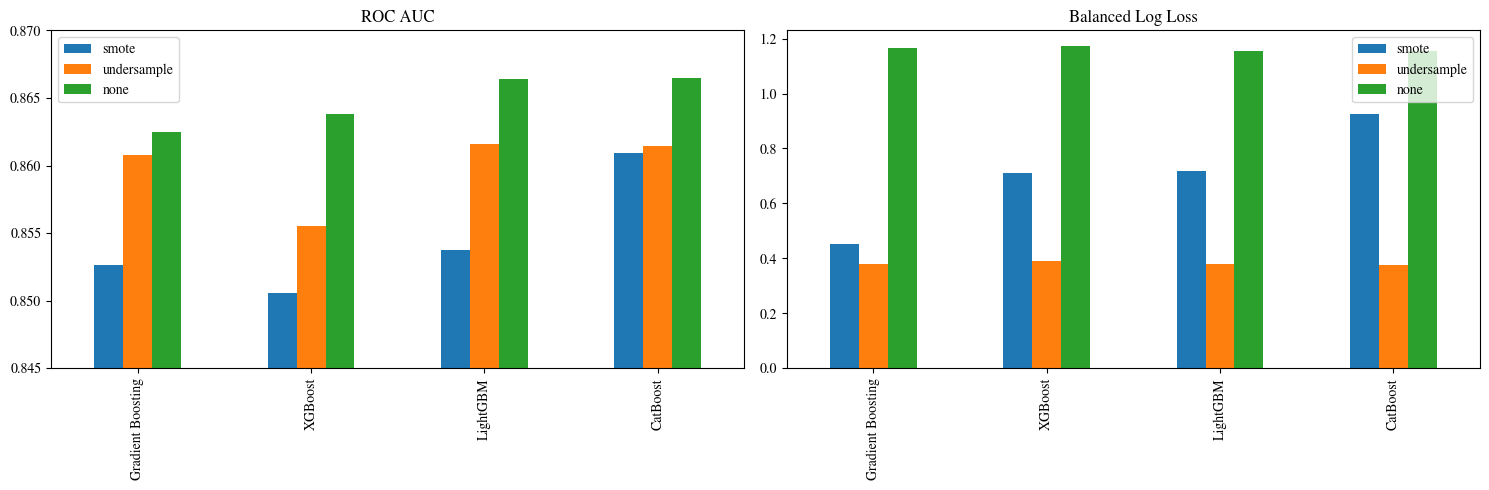

In [164]:
balance_roc_auc_tbl = balance_method_table(val_metrics_balance, metric='roc_auc')
balance_bll_tbl = balance_method_table(val_metrics_balance, metric='balanced_log_loss')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

balance_roc_auc_tbl.plot(kind='bar', ax=ax1)
ax1.set_title('ROC AUC')
ax1.set_ylim(.845, .87)
ax1.set_xlabel('')

balance_bll_tbl.plot(kind='bar', ax=ax2)
ax2.set_title('Balanced Log Loss')
ax2.set_xlabel('')

plt.tight_layout()
plt.show()

With 100k examples, the best ROC/AUC scores are achieved with
the original imbalance, while undersampling yields best balanced log loss scores. ROC/AUC may be overly optimistic with the imbalanced training data, as it is more affected by the positive class. Since this dataset has relatively few positive samples, high AUC can be achieved by accurately predicting negatives even if performance on positive cases is weaker.
In contrast, balanced log loss considers the distribution,
such that if a model is biased toward negatives, impairing learning positives, it is assigned a higher score. This is confirmed by plotting F1 and MCC.

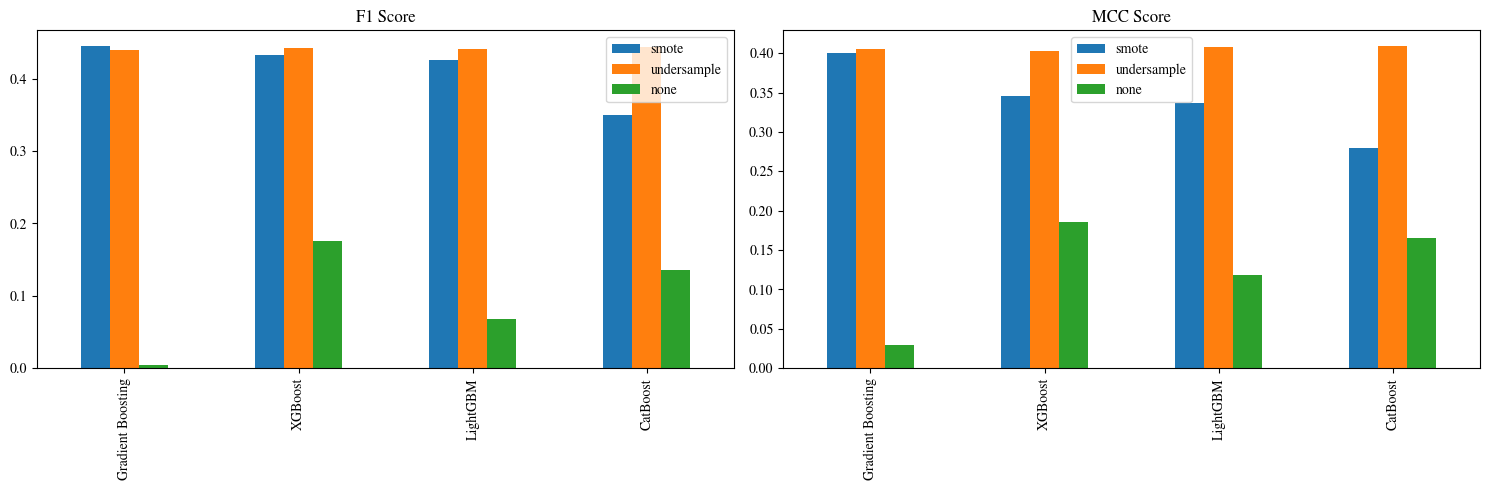

In [165]:
balance_f1_tbl = balance_method_table(val_metrics_balance, metric='f1')
balance_mcc_tbl = balance_method_table(val_metrics_balance, metric='mcc')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

balance_f1_tbl.plot(kind='bar', ax=ax1)
ax1.set_title('F1 Score')
#ax1.set_ylim(.845, .87)
ax1.set_xlabel('')

balance_mcc_tbl.plot(kind='bar', ax=ax2)
ax2.set_title('MCC Score')
ax2.set_xlabel('')

plt.tight_layout()
plt.show()

F1 and MCC are lowest without balancing, supporting the above.
Hence, undersampling appears most effective regardless of model, achieving
a good between precision and recall (high F1) while minimising balanced log loss. It also reduces training time. However, if maximising ROC/AUC was the only goal, no data balancing might be worth considering.

In [167]:
args['balancing_method'] = 'undersample'

## Feature engineering and selection

While feature engineering did not improve CV metrics of AdaBoost, it may improve the performance of one or more of these models.

In [ ]:
def interact(f1, f2):
    f1f2 = f1.astype(str) + f2.astype(str)
    return pd.factorize(f1f2)[0] + 1

In [23]:
import itertools

def create_insurance_features(df):

    df = df.copy()

    # Interaction features
    cols = df.columns
    for f1, f2 in itertools.combinations(cols, 2):
        df[f'{f1}_{f2}'] = interact(df[f1], df[f2])
        df = df.copy()

    # Derived features
    df['Vintage_minus_Vehicle_Age'] = df['Vintage'] - df['Vehicle_Age'].map({0:182.5, 1:547.5, 2: 912.5})
    df['Age_times_Driving_License'] = df['Age'] * df['Driving_License']
    df['Annual_Premium_per_Vehicle_Age'] = df['Annual_Premium'] / (df['Vehicle_Age'] + 1)  # +1 to avoid division by 0
    df['Vintage_per_Annual_Premium'] = df['Vintage'] / (df['Annual_Premium'] + 1)
    return df

In [17]:
args['N'] = 100000
X_strat, y_strat = sample_stratified(args, X, y)
X_strat = encode_data(X_strat)
X_strat_manyfeat = create_insurance_features(X_strat)
X_strat_manyfeat_scale = pd.DataFrame(scaler.fit_transform(X_strat_manyfeat))
X_strat_manyfeat_scale.shape

(100000, 59)

In [ ]:
val_metrics_manyfeat = cross_validate_models(args, models, X_strat_manyfeat_scale, y_strat)

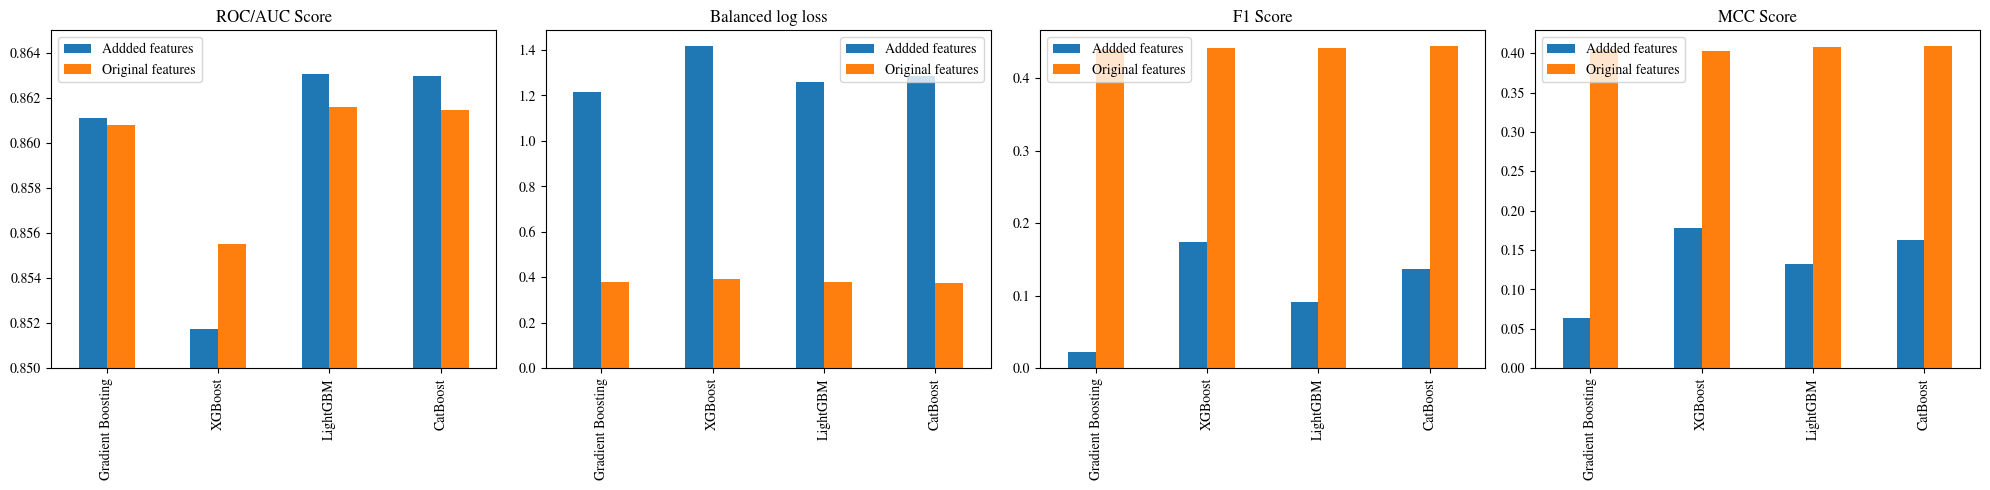

In [339]:
val_metrics = val_metrics_balance['undersample']
compare_dict = {'Addded features': val_metrics_manyfeat, 'Original features': val_metrics}

compare_auc = compare_table(compare_dict, metric='roc_auc')
compare_bll = compare_table(compare_dict, metric='balanced_log_loss')
compare_f1 = compare_table(compare_dict, metric='f1')
compare_mcc = compare_table(compare_dict, metric='mcc')

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 5))

compare_auc.plot(kind='bar', ax=ax1)
ax1.set_title('ROC/AUC Score')
ax1.set_ylim(.85, .865)

compare_bll.plot(kind='bar', ax=ax2)
ax2.set_title('Balanced log loss')

compare_f1.plot(kind='bar', ax=ax3)
ax3.set_title('F1 Score')

compare_mcc.plot(kind='bar', ax=ax4)
ax4.set_title('MCC Score')

plt.tight_layout()
plt.show()

ROC/AUC is slightly improved with the new features, but balanced log loss, F1 and MCC is significantly impaired, implying worse ability to predict the positive class. LightGBM improved the most, so I train a model to find the most important features and cross-validate across models including a few of the best new features.

In [ ]:
def get_important_feat(model, data, top_n=5, new_only=False):
    importances = model.feature_importances_
    if new_only:
        new = ~data.columns.isin(range(10))
        x, y= data.columns[new], importances[new]
    else:
        x, y = data.columns, importances
    df = pd.DataFrame({'feature': x, 'importance': y}).sort_values(
        'importance', ascending=False)
    
    return df.iloc[:top_n].reset_index(drop=True)

In [ ]:
# Get the most important features for LightGBM since this was improve the most with new features
trained_lightgbm = models[2][0].fit(X_strat_manyfeat_scale, y_strat)

In [324]:
important_feats = get_important_feat(trained_lightgbm, X_strat_manyfeat_scale, new_only=True)
X_strat_manyfeat.columns[np.array(important_feats['feature'])]

Index(['Driving_License_Vintage', 'Age_Region_Code',
       'Previously_Insured_Vintage', 'Region_Code_Vintage',
       'Vintage_Gender_Male'],
      dtype='object')

None of the derived features were amongst the five most important new features. Adding these features gives 15 in total.

In [329]:
def create_insurance_features(df):
    df = df.copy()

    # Interaction features
    df['i1'] = interact(df['Driving_License'], df['Vintage'])
    df['i2'] = interact(df['Age'], df['Region_Code'])
    df['i3'] = interact(df['Previously_Insured'], df['Vintage'])
    df['i4'] = interact(df['Region_Code'], df['Vintage'])
    df['i5'] = interact(df['Vintage'], df['Gender_Male'])
    
    return df

X_strat_15f = create_insurance_features(X_strat)
X_strat_15f_scale = pd.DataFrame(scaler.fit_transform(X_strat_15f))
X_strat_15f_scale.shape

(100000, 15)

In [333]:
val_metrics_15f = cross_validate_models(args, models, X_strat_15f_scale, y_strat)

Cross-validating: Gradient Boosting
Completed cross-validation in 96.30611753463745 seconds.
Cross-validating: XGBoost
Completed cross-validation in 16.912838459014893 seconds.
Cross-validating: LightGBM
Completed cross-validation in 20.567506313323975 seconds.
Cross-validating: CatBoost
Completed cross-validation in 89.28277397155762 seconds.


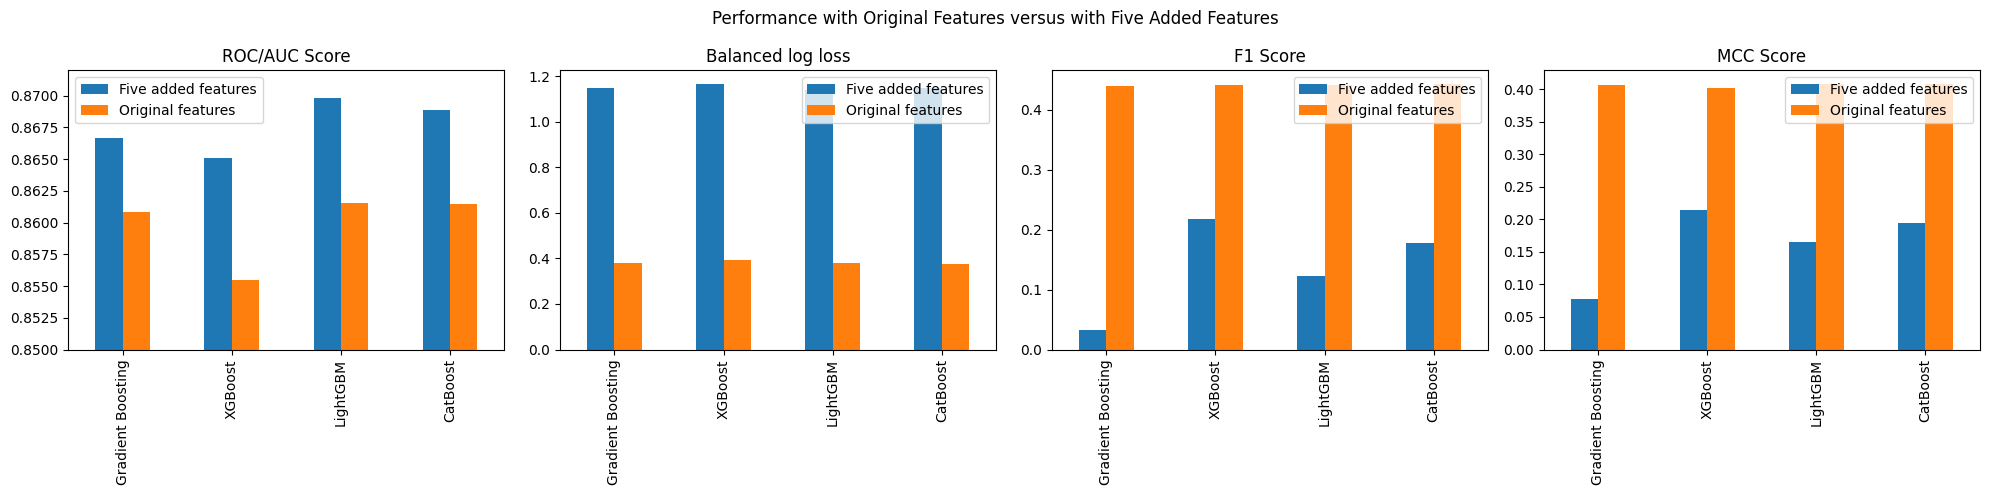

In [4]:
compare_dict = {'Five added features': val_metrics_15f, 'Original features': val_metrics}

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 5))

compare_table(compare_dict, metric='roc_auc').plot(kind='bar', ax=ax1)
ax1.set_title('ROC/AUC Score')
ax1.set_ylim(.85, .872)

compare_table(compare_dict, metric='balanced_log_loss').plot(kind='bar', ax=ax2)
ax2.set_title('Balanced log loss')

compare_table(compare_dict, metric='f1').plot(kind='bar', ax=ax3)
ax3.set_title('F1 Score')

compare_table(compare_dict, metric='mcc').plot(kind='bar', ax=ax4)
ax4.set_title('MCC Score')

fig.suptitle('Performance with Original Features versus with Five Added Features')

plt.tight_layout()
plt.show()


Adding only the 5 most important new features according to LightGBM significantly improves the ROC/AUC scores across models,
including XGBoost whose AUC was reduced with the full set.
However, balanced log loss, F1, and MCC decreased significantly.
To solely maximise ROC/AUC, I would further analyse feature subsets.
But for the best model overall, particularly with
respect to balanced log loss, engineering new features does not appear helpful here.

To demonstrate that other feature subsets yield a similar result, and to demonstrate another method of automated feature selection, I employ Correlation-Based Feature Selection (CFS) to remove redundant features by selecting those that are most correlated with the target variable but uncorrelated with each other. A feature correlation matrix is calculated to identify potential redundancies. From each group, the feature with the highest absolute correlation with the target is retained.

In [40]:
new_feat = X_strat_manyfeat.iloc[:, 10:]
corr_mat = pd.concat([new_feat, y_strat], axis=1).corr()
corr_mat.shape

(50, 50)

In [50]:
def get_correlated_features(corr_mat, threshold):
    corr_lists = {}
    
    for i in range(len(corr_mat.columns)):
        for j in range(i):
            # For each pair of features, check if their intercorrelation is above
            # the threshold. If so, add them to each other's list.
            if abs(corr_mat.iloc[i, j]) > threshold:
                f1, f2 = corr_mat.columns[i], corr_mat.columns[j]
                
                # Create the list if it doesn't exist
                if f1 not in corr_lists:
                    corr_lists[f1] = []
                if f2 not in corr_lists:
                    corr_lists[f2] = []
                
                corr_lists[f1].append(f2)
                corr_lists[f2].append(f1)
    
    return corr_lists


def get_most_important_features(corr_lists, target_corr):
    representatives = []
    
    # Iterate through the lists
    for f1, corr_list in corr_lists.items():
        rep_target_corr = target_corr.index.get_loc(f1) # lower is better     
        representative = f1
        
        for f2 in corr_list:
            f2_target_corr = target_corr.index.get_loc(f2)
            
            if f2_target_corr < rep_target_corr:
                # f2 is more correlated with target
                representative = f2
                rep_target_corr = f2_target_corr
        
        representatives.append(representative)
    
    return representatives

In [58]:
corr_lists = get_correlated_features(corr_mat, 0.9)
target_corr = corr_mat['Response'].abs().sort_values(ascending=False)
get_most_important_features(corr_lists, target_corr)

['Region_Code_Previously_Insured',
 'Region_Code_Previously_Insured',
 'Vehicle_Damage_Annual_Premium',
 'Vehicle_Damage_Annual_Premium',
 'Vehicle_Damage_Policy_Sales_Channel',
 'Vehicle_Damage_Policy_Sales_Channel',
 'Vehicle_Damage_Policy_Sales_Channel',
 'Age_Annual_Premium',
 'Age_Annual_Premium',
 'Policy_Sales_Channel_Gender_Male']

A threshold of 0.9 yields 5 new features, which form a different subset than with LightGBM importances.

In [60]:
def create_insurance_features(df):
    df = df.copy()

    # Interaction features
    df['i1'] = interact(df['Region_Code'], df['Previously_Insured'])
    df['i2'] = interact(df['Vehicle_Damage'], df['Annual_Premium'])
    df['i3'] = interact(df['Vehicle_Damage'], df['Policy_Sales_Channel'])
    df['i4'] = interact(df['Age'], df['Annual_Premium'])
    df['i5'] = interact(df['Policy_Sales_Channel'], df['Gender_Male'])
    
    return df

X_strat_corr15f = create_insurance_features(X_strat)
X_strat_corr15f_scale = pd.DataFrame(scaler.fit_transform(X_strat_corr15f))
X_strat_corr15f_scale.shape

(100000, 15)

In [62]:
val_metrics_corr15f = cross_validate_models(args, models, X_strat_corr15f_scale, y_strat)

Cross-validating: Gradient Boosting
Completed cross-validation in 95.58975124359131 seconds.
Cross-validating: XGBoost
Completed cross-validation in 14.32857632637024 seconds.
Cross-validating: LightGBM
Completed cross-validation in 17.095009803771973 seconds.
Cross-validating: CatBoost
Completed cross-validation in 79.22073316574097 seconds.


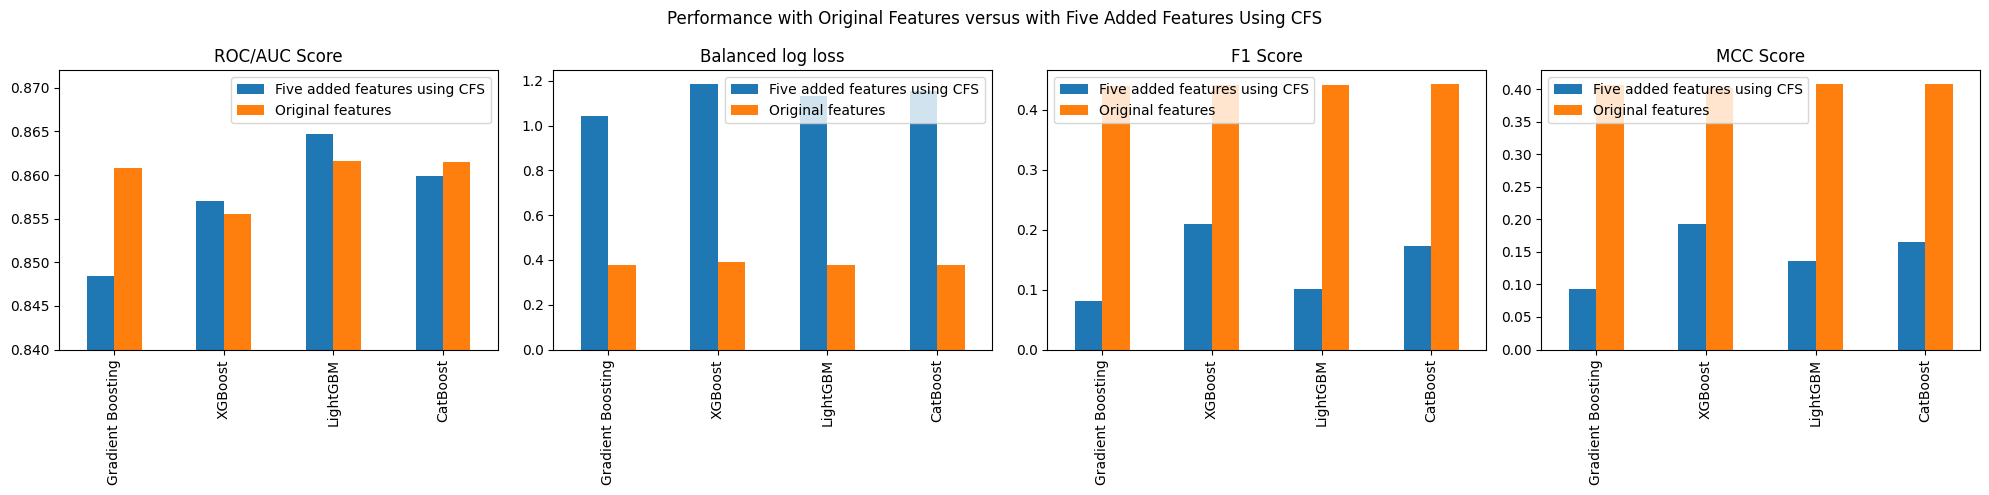

In [64]:
compare_dict = {'Five added features using CFS': val_metrics_corr15f, 'Original features': val_metrics}

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 5))

compare_table(compare_dict, metric='roc_auc').plot(kind='bar', ax=ax1)
ax1.set_title('ROC/AUC Score')
ax1.set_ylim(.84, .872)

compare_table(compare_dict, metric='balanced_log_loss').plot(kind='bar', ax=ax2)
ax2.set_title('Balanced log loss')

compare_table(compare_dict, metric='f1').plot(kind='bar', ax=ax3)
ax3.set_title('F1 Score')

compare_table(compare_dict, metric='mcc').plot(kind='bar', ax=ax4)
ax4.set_title('MCC Score')

fig.suptitle('Performance with Original Features versus with Five Added Features Using CFS')

plt.tight_layout()
plt.show()

Again, worse log loss, F1 and MCC scores. This method also improved ROC/AUC less than the previous one.
It is usually better to remove fewer features at a time. However, I avoid dwelling on this as I predict any subset will yield a similar pattern.

## Hyperparameter tuning

Top 4 models based on balanced_log_loss:
CatBoost: 0.3755571307891171
Gradient Boosting: 0.3782483311771365
LightGBM: 0.37871530178812046
XGBoost: 0.39198261452030636


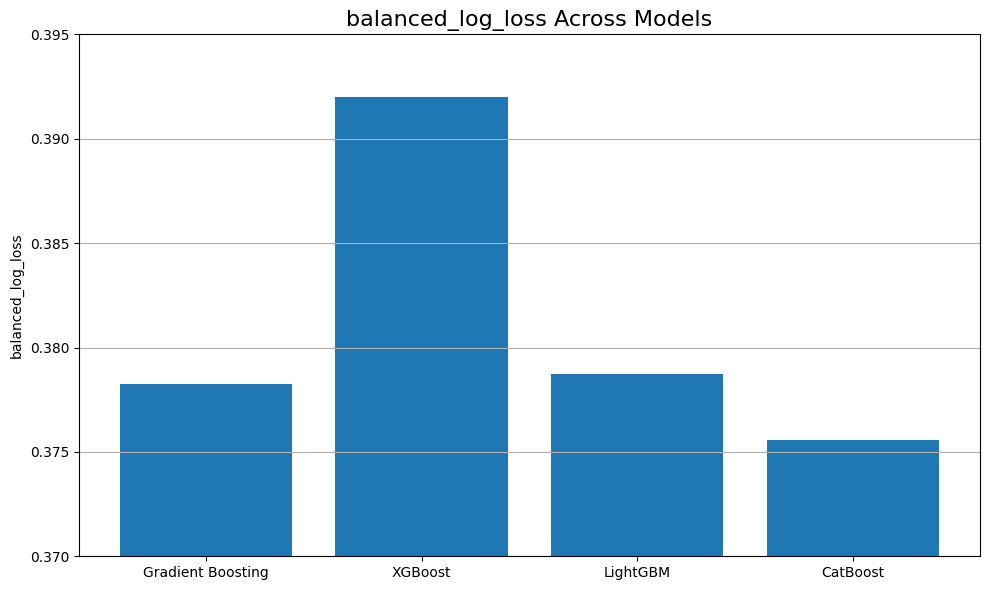

In [27]:
import matplotlib.pyplot as plt

def plot_best_models(val_metrics, metric='balanced_log_loss', y_range=(.37, .395)):
    models = list(val_metrics.keys())
    metric_values = [val_metrics[i][metric] for i in models]
    
    plt.figure(figsize=(10, 6))
    plt.bar(models, metric_values)
    
    plt.title(f'{metric} Across Models', fontsize=16)
    plt.ylabel(metric)
    
    plt.grid(axis='y')
    plt.ylim(y_range)

    plt.tight_layout()
    plt.show()

print_best_models(val_metrics, 'balanced_log_loss', higher_is_better=False, n_models=4)
plot_best_models(val_metrics)

Balanced log loss is similar across models, with CatBoost lowest (0.376).
CatBoost also shows strongest performance across metrics,
so I focus on this model in tuning.
CatBoost is a high-performance implementation of the gradient-boosted decision trees algorithm. It includes ordered boosting and a special algorithm for processing categorical features, both motivated by reducing prediction shift in gradient boosting algorithms.
For tuning, I use Optuna with the Tree-structured Parzen Estimator (TPE) sampling strategy, which iteratively suggests hyperparameter combinations based on previous results. I use log loss for the loss function and optimise for minimising balanced log loss.

Search space:
- learning rate, between 0.01 and 0.1 (lower values usually perform better while increasing training time)
- the number of iterations, between 50 and 1000 (more rounds usually improves performance but may cause overfitting)
- maximum tree depth, between 5 and 10 (higher values may increase the intricacy of learned data patterns at the risk of overfitting)
- random strength, between 0 and 10 (adds randomness to the split points to improve robustness)
- the L2 regularisation term, between 0.1 and 10 (penalises large weights to avoid overfitting)
- bagging temperature, between 0 and 1 (affects randomness in bagging, with lower values adding more randomness when selecting samples)
- border count, between 32 and 400 (controls the number of splits for numerical features, with more increasing granularity plus computational load)
- leaf estimation iterations, between 1 and 10 (controls the iterations for leaf estimation, with more potentially improving their accuracy)
- one-hot maximum size, between 2 and 10 (determines the cardinality threshold for categorical features to apply one-hot encoding: if the number of unique values exceeds this, a more efficient method is used)

I use suggest_float(..., log=True) for hyperparameters with a multiplicative impact with larger ranges, and suggest_float() for those with additive effects and smaller ranges.

In [6]:
import optuna

def objective(trial):
    params = {
        'random_seed': args['random_state'],
        'task_type': 'GPU' if args['use_gpu'] else 'CPU',
        'verbose': False,
        'iterations': trial.suggest_int('iterations', 50, 1000),
        'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations', 1, 5),
        'one_hot_max_size': trial.suggest_int('one_hot_max_size', 2, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'depth': trial.suggest_int('depth', 5, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'random_strength': trial.suggest_float('random_strength', 0.1, 10, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.1, 10, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 0.5)
    }
    
    classifier = CatBoostClassifier(**params)

    results = train_k_fold(args, classifier, X_strat, y_strat, k=5, stratified=True, parallel=False)
    metrics = avg_metrics([results[i][3] for i in range(len(results))])
    balanced_log_loss = metrics['balanced_log_loss']

    return balanced_log_loss

In [10]:
args['use_gpu'] = True
args['balance_method'] = 'undersample'
optuna.logging.set_verbosity(optuna.logging.ERROR)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)
best_catboost_params = study.best_params

Completed cross-validation in 116.25021028518677 seconds.
Completed cross-validation in 137.34081983566284 seconds.
Completed cross-validation in 10.217899560928345 seconds.
Completed cross-validation in 47.853249311447144 seconds.
Completed cross-validation in 108.26566886901855 seconds.
Completed cross-validation in 17.311049461364746 seconds.
Completed cross-validation in 63.44300103187561 seconds.
Completed cross-validation in 9.179269790649414 seconds.
Completed cross-validation in 10.170323610305786 seconds.
Completed cross-validation in 113.97763204574585 seconds.
Completed cross-validation in 64.93972444534302 seconds.
Completed cross-validation in 70.2051854133606 seconds.
Completed cross-validation in 63.75858807563782 seconds.
Completed cross-validation in 55.28596353530884 seconds.
Completed cross-validation in 14.982447147369385 seconds.
Completed cross-validation in 79.98402738571167 seconds.
Completed cross-validation in 18.976990461349487 seconds.
Completed cross-valida

In [12]:
best_catboost_params

{'iterations': 762,
 'leaf_estimation_iterations': 3,
 'one_hot_max_size': 7,
 'border_count': 251,
 'depth': 8,
 'learning_rate': 0.040119755120788976,
 'random_strength': 0.6899781237737079,
 'l2_leaf_reg': 9.38242905306816,
 'bagging_temperature': 0.44127372452553676}

In [16]:
catboost = CatBoostClassifier(verbose=False, task_type='GPU', **best_catboost_params)
catboost_results = train_k_fold(args, catboost, X_strat, y_strat, k=5, stratified=True, parallel=False)
catboost_metrics = avg_metrics([catboost_results[i][3] for i in range(len(catboost_results))])

Completed cross-validation in 144.4459855556488 seconds.


In [17]:
catboost_metrics

{'precision': 0.29110910250355015,
 'recall': 0.9236274908499389,
 'f1': 0.44268761768378984,
 'accuracy': 0.7140557027851392,
 'mcc': 0.40953347960675196,
 'kappa': 0.3145161954168676,
 'lift': 2.3675847665589673,
 'roc_auc': 0.865211535313694,
 'balanced_log_loss': 0.3652504898986704}

In [33]:
catboost_metrics_no_tuning = val_metrics['CatBoost']

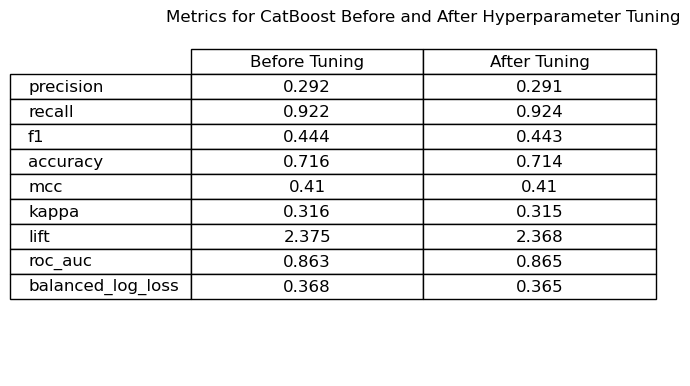

In [44]:
metrics = list(catboost_metrics.keys())

dicts = [catboost_metrics_no_tuning, catboost_metrics]
data = np.array([[d[metric] for d in dicts] for metric in metrics])
data = np.round(data, 3)

fig, ax = plt.subplots(figsize=(4,1))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=data, colLabels=['Before Tuning', 'After Tuning'],
                 rowLabels=metrics,cellLoc='center', loc='top')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 1.5)
plt.title("Metrics for CatBoost Before and After Hyperparameter Tuning", fontsize=12, pad=200)
plt.show()

plt.show()

Tuning has a modest impact on CatBoost's overall performance.
Balanced log loss, ROC/AUC and recall slightly improve, while other metrics do not. The tuned model appears slighlty more sensitive but less selective toward the positive class.

## Full training and Kaggle score

In [4]:
df_train = pd.read_csv(args['base_dir'] + 'train.csv')
X, y = split_response(df_train)
X, y = undersample_neg(args, X, y, adaboost_labels=False)
X = encode_data(X)

In [6]:
catboost = CatBoostClassifier(verbose=False, task_type='GPU', **best_catboost_params)
catboost.fit(X, y)

In [7]:
df_test = pd.read_csv(args['base_dir'] + 'test.csv') 
X_test = encode_data(df_test)
test_prob = catboost.predict_proba(X_test)[:, 1]
submit =  pd.concat([df_test['id'], pd.Series(test_prob)], axis=1).rename(columns={0: "Response"})
submit.head()

,id,Response
0,11504798,0.058169
1,11504799,0.810642
2,11504800,0.709217
3,11504801,0.000754
4,11504802,0.257480


In [8]:
submit.to_csv('/kaggle/working/t3submission.csv', index=False)

This obtained a score of 0.87623, beating my AdaBoost implementation (0.87432). This might be improved by prioritising ROC/AUC over all other metrics (e.g., using imbalanced data and combination features), but my objective was to produce a good overall model, which should incorperate other metrics such as balanced log loss.